# Step 4: The Multi-Model ML Pipeline

Because this is a spatio-temporal crisis detection system, we don't rely on just one model.
We deploy an **ensemble of three models**, each answering a different question about our earthquake matrix:

| Model | Question It Answers |
|---|---|
| **Isolation Forest** | Where is an anomaly currently happening on the map? |
| **XGBoost Regressor** | Given yesterday's numbers and neighbor patterns, how many events should we expect tomorrow? |
| **Prophet** | Is this specific hexagon's behavior significantly diverging from its long-term historical baseline? |

Each model is trained sequentially and its predictions are merged into a unified `test_results` DataFrame.

In [12]:
import polars as pl
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the chronological splits from Step 3
train_df = pl.read_csv('ml_train_split.csv', try_parse_dates=True)
val_df   = pl.read_csv('ml_val_split.csv', try_parse_dates=True)
test_df  = pl.read_csv('ml_test_split.csv', try_parse_dates=True)

# Define feature and target columns
feature_cols = ['lag_1_day', 'lag_2_day', 'lag_7_day', 'rolling_mean_3_day', 'neighbor_pressure_index']
target_col   = 'event_count'

# Build numpy arrays for sklearn/xgboost
X_train = train_df.select(feature_cols).to_numpy()
y_train = train_df.select(target_col).to_numpy().flatten()
X_val   = val_df.select(feature_cols).to_numpy()
y_val   = val_df.select(target_col).to_numpy().flatten()
X_test  = test_df.select(feature_cols).to_numpy()
y_test  = test_df.select(target_col).to_numpy().flatten()

print('Data loaded and arrays prepared.')
print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')

Data loaded and arrays prepared.
Train: (440033, 5)  |  Val: (145332, 5)  |  Test: (141295, 5)


---
## Model 1: Isolation Forest (Spatial Anomaly Detection)

The Isolation Forest scans the `neighbor_pressure_index` and current feature vector
to assign an **anomaly score** to each data block. Points that are easy to isolate
(far from the dense cluster of normal behavior) receive low anomaly scores.

We set `contamination=0.05`, assuming the top 5% of seismic spikes are true crises.
The model fits on the training distribution, then scores all three splits.

In [13]:
from sklearn.ensemble import IsolationForest

# 1. Initialize the model
# contamination=0.05 -> top 5% of seismic spikes are flagged as true crises
iso_forest = IsolationForest(n_estimators=150, contamination=0.05, random_state=42)

# 2. Fit on training data
iso_forest.fit(X_train)

# 3. Score and predict on ALL THREE splits
train_anomaly_scores = iso_forest.decision_function(X_train)
train_anomaly_labels = iso_forest.predict(X_train)

val_anomaly_scores = iso_forest.decision_function(X_val)
val_anomaly_labels = iso_forest.predict(X_val)

test_anomaly_scores = iso_forest.decision_function(X_test)
test_anomaly_labels = iso_forest.predict(X_test)

# 4. Map test predictions back to our structural test DataFrame
test_results = test_df.with_columns([
    pl.Series("anomaly_score", test_anomaly_scores),
    pl.Series("is_anomaly", test_anomaly_labels).map_elements(lambda x: 1 if x == -1 else 0, return_dtype=pl.Int32)
])

print("Isolation Forest training complete.")

Isolation Forest training complete.


### Isolation Forest — Results Across All Splits

Since Isolation Forest is an unsupervised anomaly detector (no ground-truth labels),
we report the **number and percentage of anomalies detected** and the
**distribution of anomaly scores** across each split.

In [14]:
# Isolation Forest results for all three splits
def iso_forest_summary(name, scores, labels, y_actual):
    n_anomalies = int((labels == -1).sum())
    total = len(labels)
    pct = n_anomalies / total * 100
    # Among flagged anomalies, what is the mean actual event count?
    anomaly_mask = labels == -1
    mean_actual_anomaly = y_actual[anomaly_mask].mean() if anomaly_mask.sum() > 0 else 0
    mean_actual_normal  = y_actual[~anomaly_mask].mean()
    print(f"  {name:12s} | Total: {total:>8,} | Anomalies: {n_anomalies:>6,} ({pct:5.2f}%) "
          f"| Avg score: {scores.mean():+.4f} "
          f"| Mean event_count [anomaly]: {mean_actual_anomaly:.3f}  [normal]: {mean_actual_normal:.3f}")

print("=" * 120)
print("ISOLATION FOREST — Anomaly Detection Results")
print("=" * 120)
iso_forest_summary("TRAIN", train_anomaly_scores, train_anomaly_labels, y_train)
iso_forest_summary("VALIDATION", val_anomaly_scores, val_anomaly_labels, y_val)
iso_forest_summary("TEST", test_anomaly_scores, test_anomaly_labels, y_test)
print("=" * 120)

ISOLATION FOREST — Anomaly Detection Results
  TRAIN        | Total:  440,033 | Anomalies: 18,513 ( 4.21%) | Avg score: -0.0149 | Mean event_count [anomaly]: 0.326  [normal]: 0.000
  VALIDATION   | Total:  145,332 | Anomalies:  6,323 ( 4.35%) | Avg score: -0.0155 | Mean event_count [anomaly]: 0.354  [normal]: 0.000
  TEST         | Total:  141,295 | Anomalies:  5,080 ( 3.60%) | Avg score: -0.0127 | Mean event_count [anomaly]: 0.294  [normal]: 0.000


---
## Model 2: XGBoost Regressor (Short-Term Trend Risk Forecasting)

XGBoost trains gradient-boosted decision trees on our temporal and spatial features.
The validation set implements **early stopping** — if the model's performance plateaus
or worsens on the validation horizon, training halts to prevent overfitting to
temporary, random seismic noise.

**Key Hyperparameters:**
- `n_estimators=200`: Maximum 200 boosting rounds
- `max_depth=5`: Each tree can capture moderately complex interactions
- `learning_rate=0.05`: Conservative step size for stability
- `reg_lambda=1.5`: L2 regularization penalty to prevent tree overfitting

In [15]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Instantiate the Regressor with structural regularization
xgb_regressor = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    reg_lambda=1.5,  # L2 regularization penalty
    random_state=42
)

# 2. Train the model with validation monitoring
xgb_regressor.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 3. Predict on ALL THREE splits
xgb_pred_train = xgb_regressor.predict(X_train)
xgb_pred_val   = xgb_regressor.predict(X_val)
xgb_pred_test  = xgb_regressor.predict(X_test)

# 4. Attach test predictions to test_results
test_results = test_results.with_columns(pl.Series("xgb_predicted_count", xgb_pred_test))

print("XGBoost training complete.")

XGBoost training complete.


### XGBoost — Results Across All Splits

We evaluate regression metrics on train, validation, and test:
- **MAE** (Mean Absolute Error): Average prediction error in event counts
- **MSE** (Mean Squared Error): Penalizes large errors more heavily
- **RMSE** (Root MSE): Same units as event counts
- **R²** (Coefficient of Determination): 1.0 = perfect, 0.0 = baseline mean

A healthy model shows Train R² > Val R² ≈ Test R² (no severe overfitting).

In [16]:
# XGBoost regression metrics for all three splits
def xgb_summary(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:12s} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

print("=" * 90)
print("XGBOOST REGRESSOR — Regression Metrics")
print("=" * 90)
xgb_summary("TRAIN",      y_train, xgb_pred_train)
xgb_summary("VALIDATION", y_val,   xgb_pred_val)
xgb_summary("TEST",       y_test,  xgb_pred_test)
print("=" * 90)
print(f"\nActual event_count distribution:")
print(f"  Train mean: {y_train.mean():.4f} | Val mean: {y_val.mean():.4f} | Test mean: {y_test.mean():.4f}")
print(f"  Train std:  {y_train.std():.4f} | Val std:  {y_val.std():.4f} | Test std:  {y_test.std():.4f}")
print(f"  Train max:  {y_train.max()}      | Val max:  {y_val.max()}      | Test max:  {y_test.max()}")

XGBOOST REGRESSOR — Regression Metrics
  TRAIN        | MAE: 0.0010 | MSE: 0.0004 | RMSE: 0.0202 | R²: 0.9896
  VALIDATION   | MAE: 0.0023 | MSE: 0.0300 | RMSE: 0.1732 | R²: 0.6314
  TEST         | MAE: 0.0009 | MSE: 0.0006 | RMSE: 0.0237 | R²: 0.9706

Actual event_count distribution:
  Train mean: 0.0137 | Val mean: 0.0154 | Test mean: 0.0106
  Train std:  0.1974 | Val std:  0.2853 | Test std:  0.1383
  Train max:  63      | Val max:  78      | Test max:  14


---
## Model 3: Prophet (Temporal Baseline Curve Fitting)

Unlike XGBoost and Isolation Forest, which look at all rows simultaneously,
**Prophet builds a tailored curve for individual locations**. It decomposes each
hexagon's time series into trend + seasonality + noise, then flags days where the
actual count significantly exceeds the predicted upper bound (`yhat_upper`).

### Computational Optimization
Running Prophet on all 4,000+ hexagons is prohibitively expensive.
We only fit Prophet on the **top 20 most active hexagons** (by total historical event count),
since these are the locations where temporal divergence actually matters for crisis detection.
All other hexagons receive a default `prophet_divergence = 0`.

In [17]:
from prophet import Prophet

# 1. Identify the top 20 most active hexagons across the full dataset
full_df = pl.concat([train_df, val_df, test_df])
top_hexes = (
    full_df.group_by('h3_index')
    .agg(pl.col('event_count').sum().alias('total_events'))
    .sort('total_events', descending=True)
    .head(20)
    .select('h3_index')
    .to_series()
    .to_list()
)
print(f"Running Prophet on top {len(top_hexes)} active hexagons...")

# 2. Build per-hexagon Prophet models and store results for ALL splits
prophet_results = {}  # key: hex_id, value: dict with train/val/test metrics
prophet_divergences_train = {}
prophet_divergences_val   = {}
prophet_divergences_test  = {}

for i, hex_id in enumerate(top_hexes):
    # Prophet requires columns named 'ds' (date) and 'y' (value)
    hex_train_val = (
        pl.concat([train_df, val_df])
        .filter(pl.col('h3_index') == hex_id)
        .select([
            pl.col('date_bucket').alias('ds'),
            pl.col('event_count').cast(pl.Float64).alias('y')
        ])
        .sort('ds')
        .to_pandas()
    )
    
    hex_train_only = (
        train_df.filter(pl.col('h3_index') == hex_id)
        .select([
            pl.col('date_bucket').alias('ds'),
            pl.col('event_count').cast(pl.Float64).alias('y_actual')
        ]).sort('ds').to_pandas()
    )
    
    hex_val_only = (
        val_df.filter(pl.col('h3_index') == hex_id)
        .select([
            pl.col('date_bucket').alias('ds'),
            pl.col('event_count').cast(pl.Float64).alias('y_actual')
        ]).sort('ds').to_pandas()
    )
    
    hex_test = (
        test_df.filter(pl.col('h3_index') == hex_id)
        .select([
            pl.col('date_bucket').alias('ds'),
            pl.col('event_count').cast(pl.Float64).alias('y_actual')
        ]).sort('ds').to_pandas()
    )
    
    if len(hex_train_val) < 14 or len(hex_test) == 0:
        continue
    
    # Fit Prophet on train+val history
    model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    model.fit(hex_train_val)
    
    # Forecast covering the full range (train + val + test)
    future = model.make_future_dataframe(periods=len(hex_test), freq='D')
    forecast = model.predict(future)
    
    # --- Compute divergences for TRAIN split ---
    fc_train = forecast.head(len(hex_train_only)).reset_index(drop=True)
    hex_train_only = hex_train_only.reset_index(drop=True)
    if len(fc_train) == len(hex_train_only):
        div_train = np.clip(hex_train_only['y_actual'].values - fc_train['yhat_upper'].values, 0, None)
        for ds_val, div_val in zip(hex_train_only['ds'].values, div_train):
            prophet_divergences_train[(str(ds_val)[:10], hex_id)] = float(div_val)
    
    # --- Compute divergences for VALIDATION split ---
    fc_val = forecast.iloc[len(hex_train_only):len(hex_train_only)+len(hex_val_only)].reset_index(drop=True)
    hex_val_only = hex_val_only.reset_index(drop=True)
    if len(fc_val) == len(hex_val_only):
        div_val_arr = np.clip(hex_val_only['y_actual'].values - fc_val['yhat_upper'].values, 0, None)
        for ds_val, div_val in zip(hex_val_only['ds'].values, div_val_arr):
            prophet_divergences_val[(str(ds_val)[:10], hex_id)] = float(div_val)
    
    # --- Compute divergences for TEST split ---
    forecast_test = forecast.tail(len(hex_test)).reset_index(drop=True)
    hex_test = hex_test.reset_index(drop=True)
    divergence = np.clip(hex_test['y_actual'].values - forecast_test['yhat_upper'].values, 0, None)
    for ds_val, div_val in zip(hex_test['ds'].values, divergence):
        prophet_divergences_test[(str(ds_val)[:10], hex_id)] = float(div_val)
    
    # Store per-hex summary
    prophet_results[hex_id] = {
        'train_peak_div': float(div_train.max()) if len(fc_train) == len(hex_train_only.reset_index(drop=True)) else 0,
        'val_peak_div': float(div_val_arr.max()) if len(fc_val) == len(hex_val_only) else 0,
        'test_peak_div': float(divergence.max()),
        'train_nonzero': int((div_train > 0).sum()) if len(fc_train) == len(hex_train_only) else 0,
        'val_nonzero': int((div_val_arr > 0).sum()) if len(fc_val) == len(hex_val_only) else 0,
        'test_nonzero': int((divergence > 0).sum())
    }
    
    print(f"  [{i+1}/{len(top_hexes)}] {hex_id} -> Train peak: {prophet_results[hex_id]['train_peak_div']:.2f} "
          f"| Val peak: {prophet_results[hex_id]['val_peak_div']:.2f} "
          f"| Test peak: {prophet_results[hex_id]['test_peak_div']:.2f}")

print(f"\nProphet analysis complete.")

Running Prophet on top 20 active hexagons...


11:32:14 - cmdstanpy - INFO - Chain [1] start processing
11:32:14 - cmdstanpy - INFO - Chain [1] done processing
11:32:14 - cmdstanpy - INFO - Chain [1] start processing


  [1/20] 8468c97ffffffff -> Train peak: 6.06 | Val peak: 64.84 | Test peak: 0.00


11:32:14 - cmdstanpy - INFO - Chain [1] done processing
11:32:15 - cmdstanpy - INFO - Chain [1] start processing


  [2/20] 84165e3ffffffff -> Train peak: 8.89 | Val peak: 0.98 | Test peak: 0.00


...

  [18/20] 84aa26dffffffff -> Train peak: 12.42 | Val peak: 0.00 | Test peak: 0.00


11:32:20 - cmdstanpy - INFO - Chain [1] start processing


  [19/20] 84165a9ffffffff -> Train peak: 2.03 | Val peak: 1.01 | Test peak: 0.13


11:32:20 - cmdstanpy - INFO - Chain [1] done processing


  [20/20] 8416ac5ffffffff -> Train peak: 1.13 | Val peak: 0.31 | Test peak: 0.44

Prophet analysis complete.


### Prophet — Results Across All Splits

Prophet divergence measures how far above the **upper confidence bound** the actual
event count went. Non-zero divergence = the hexagon breached its expected baseline.

In [18]:
# Prophet summary across all splits
print("=" * 100)
print("PROPHET — Temporal Divergence Results (Top 20 Hexagons)")
print("=" * 100)
print(f"{'Hexagon':<20} {'Train Peak':>12} {'Train #>0':>10} {'Val Peak':>12} {'Val #>0':>10} {'Test Peak':>12} {'Test #>0':>10}")
print("-" * 100)
for hex_id, metrics in prophet_results.items():
    print(f"{hex_id:<20} {metrics['train_peak_div']:>12.2f} {metrics['train_nonzero']:>10} "
          f"{metrics['val_peak_div']:>12.2f} {metrics['val_nonzero']:>10} "
          f"{metrics['test_peak_div']:>12.2f} {metrics['test_nonzero']:>10}")
print("-" * 100)

# Aggregate totals
total_train_div = sum(1 for v in prophet_divergences_train.values() if v > 0)
total_val_div   = sum(1 for v in prophet_divergences_val.values() if v > 0)
total_test_div  = sum(1 for v in prophet_divergences_test.values() if v > 0)
print(f"{'TOTAL':<20} {'':>12} {total_train_div:>10} {'':>12} {total_val_div:>10} {'':>12} {total_test_div:>10}")
print("=" * 100)

PROPHET — Temporal Divergence Results (Top 20 Hexagons)
Hexagon                Train Peak  Train #>0     Val Peak    Val #>0    Test Peak   Test #>0
----------------------------------------------------------------------------------------------------
8468c97ffffffff              6.06          1        64.84          3         0.00          0
84165e3ffffffff              8.89         12         0.98          2         0.00          0
8422c47ffffffff             53.11          2         0.00          0         0.00          0
840c6ddffffffff             21.11          2         0.00          0         0.00          0
846853bffffffff             26.25          5         0.00          0         0.00          0
844cec1ffffffff             13.83          2        10.73          3         0.00          0
8416acdffffffff              7.63          9         0.00          0         2.29          1
844ceddffffffff             18.44          2         0.00          0         0.00          0
8468c9

### Merge Prophet Divergence into Test Results

We map the per-hexagon Prophet divergence scores back into the unified `test_results`
DataFrame. Hexagons not in the top 20 receive `prophet_divergence = 0.0`.

In [19]:
# Map prophet divergence back to the test_results DataFrame
prophet_div_values = []
for row in test_results.iter_rows(named=True):
    date_str = str(row['date_bucket'])
    hex_id = row['h3_index']
    div = prophet_divergences_test.get((date_str, hex_id), 0.0)
    prophet_div_values.append(div)

test_results = test_results.with_columns(
    pl.Series("prophet_divergence", prophet_div_values, dtype=pl.Float64)
)

print(f"Prophet divergence merged. Non-zero divergence entries: {test_results.filter(pl.col('prophet_divergence') > 0).height}")

Prophet divergence merged. Non-zero divergence entries: 29


---
## Consolidated Results — All Models, All Splits

This summary table gives a bird's-eye view of how each model performed
across Training, Cross-Validation, and Test datasets.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "#" * 110)
print("#  CONSOLIDATED MODEL RESULTS — TRAIN / VALIDATION / TEST")
print("#" * 110)

# ---- Isolation Forest ----
print("\n" + "=" * 110)
print("MODEL 1: ISOLATION FOREST (Unsupervised Anomaly Detection)")
print("=" * 110)
print(f"{'Split':<15} {'Rows':>10} {'Anomalies':>12} {'Anomaly %':>12} {'Avg Score':>14} {'Avg Score (Anomaly)':>22} {'Avg Score (Normal)':>22}")
print("-" * 110)

for name, scores, labels in [
    ('TRAIN',      train_anomaly_scores, train_anomaly_labels),
    ('VALIDATION', val_anomaly_scores,   val_anomaly_labels),
    ('TEST',       test_anomaly_scores,  test_anomaly_labels)
]:
    n_anom = int((labels == -1).sum())
    total = len(labels)
    pct = n_anom / total * 100
    avg_all = scores.mean()
    avg_anom = scores[labels == -1].mean() if n_anom > 0 else 0
    avg_norm = scores[labels == 1].mean()
    print(f"{name:<15} {total:>10,} {n_anom:>12,} {pct:>11.2f}% {avg_all:>+14.4f} {avg_anom:>+22.4f} {avg_norm:>+22.4f}")
print("=" * 110)

# ---- XGBoost ----
print("\n" + "=" * 110)
print("MODEL 2: XGBOOST REGRESSOR (Supervised Trend Forecasting)")
print("=" * 110)
print(f"{'Split':<15} {'Rows':>10} {'MAE':>12} {'MSE':>12} {'RMSE':>12} {'R²':>12} {'Actual Mean':>14} {'Pred Mean':>14}")
print("-" * 110)

for name, y_true, y_pred in [
    ('TRAIN',      y_train, xgb_pred_train),
    ('VALIDATION', y_val,   xgb_pred_val),
    ('TEST',       y_test,  xgb_pred_test)
]:
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<15} {len(y_true):>10,} {mae:>12.4f} {mse:>12.4f} {rmse:>12.4f} {r2:>12.4f} {y_true.mean():>14.4f} {y_pred.mean():>14.4f}")
print("=" * 110)

# ---- Prophet ----
print("\n" + "=" * 110)
print("MODEL 3: PROPHET (Temporal Baseline Divergence — Top 20 Hexagons)")
print("=" * 110)
print(f"{'Split':<15} {'Total Predictions':>20} {'Divergence >0':>16} {'Max Divergence':>16}")
print("-" * 110)

for name, divs in [
    ('TRAIN',      prophet_divergences_train),
    ('VALIDATION', prophet_divergences_val),
    ('TEST',       prophet_divergences_test)
]:
    total = len(divs)
    nonzero = sum(1 for v in divs.values() if v > 0)
    max_div = max(divs.values()) if divs else 0
    print(f"{name:<15} {total:>20,} {nonzero:>16,} {max_div:>16.2f}")
print("=" * 110)


##############################################################################################################
#  CONSOLIDATED MODEL RESULTS — TRAIN / VALIDATION / TEST
##############################################################################################################

MODEL 1: ISOLATION FOREST (Unsupervised Anomaly Detection)
Split                 Rows    Anomalies    Anomaly %      Avg Score    Avg Score (Anomaly)     Avg Score (Normal)
--------------------------------------------------------------------------------------------------------------
TRAIN              440,033       18,513        4.21%        -0.0149                -0.3532                +0.0000
VALIDATION         145,332        6,323        4.35%        -0.0155                -0.3555                +0.0000
TEST               141,295        5,080        3.60%        -0.0127                -0.3530                +0.0000

MODEL 2: XGBOOST REGRESSOR (Supervised Trend Forecasting)
Split                 Rows       

---
## Unified Test Results Preview

| Column | Source Model | What It Tells Us |
|---|---|---|
| `anomaly_score` | Isolation Forest | Continuous outlier score (lower = more anomalous) |
| `is_anomaly` | Isolation Forest | Binary anomaly flag (1 = crisis candidate) |
| `xgb_predicted_count` | XGBoost | Expected event count for tomorrow |
| `prophet_divergence` | Prophet | How far above baseline this hexagon is trending |

In [21]:
print(f"Final test_results shape: {test_results.shape}")
print(f"\nColumns: {test_results.columns}")
print(f"\nAnomalies detected (Isolation Forest): {test_results.filter(pl.col('is_anomaly') == 1).height}")
print(f"Prophet divergence events (>0): {test_results.filter(pl.col('prophet_divergence') > 0).height}")

# Show a sample of flagged anomalies with all model outputs
test_results.filter(pl.col('is_anomaly') == 1).select([
    'date_bucket', 'h3_index', 'event_count',
    'anomaly_score', 'is_anomaly',
    'xgb_predicted_count', 'prophet_divergence'
]).head(15)

Final test_results shape: (141295, 14)

Columns: ['date_bucket', 'h3_index', 'event_count', 'peak_intensity', 'energy_output', 'lag_1_day', 'lag_2_day', 'lag_7_day', 'rolling_mean_3_day', 'neighbor_pressure_index', 'anomaly_score', 'is_anomaly', 'xgb_predicted_count', 'prophet_divergence']

Anomalies detected (Isolation Forest): 5080
Prophet divergence events (>0): 29


date_bucket,h3_index,event_count,anomaly_score,is_anomaly,xgb_predicted_count,prophet_divergence
date,str,i64,f64,i32,f32,f64
2026-06-03,"""8400405ffffffff""",2,-0.339881,1,2.040347,0.0
2026-06-04,"""8400405ffffffff""",0,-0.405583,1,0.034251,0.0
2026-06-05,"""8400405ffffffff""",0,-0.403638,1,0.029691,0.0
2026-06-10,"""8400405ffffffff""",0,-0.370424,1,0.00006,0.0
2026-05-28,"""8400515ffffffff""",1,-0.300596,1,0.980518,0.0
…,…,…,…,…,…,…
2026-05-30,"""840051dffffffff""",0,-0.373208,1,0.008115,0.0
2026-06-04,"""840051dffffffff""",0,-0.356672,1,0.00006,0.0
2026-05-16,"""8401595ffffffff""",1,-0.300596,1,0.980518,0.0


## Save Pipeline Outputs

We persist the unified test results for downstream use in
Step 5 (Composite Risk Scoring) and Step 6 (Dashboard Visualization).

In [22]:
test_results.write_csv('ml_pipeline_test_results.csv')
print('Saved ml_pipeline_test_results.csv')
print(f'Shape: {test_results.shape[0]:,} rows x {test_results.shape[1]} columns')
print(f'\nModel output columns added: anomaly_score, is_anomaly, xgb_predicted_count, prophet_divergence')

Saved ml_pipeline_test_results.csv
Shape: 141,295 rows x 14 columns

Model output columns added: anomaly_score, is_anomaly, xgb_predicted_count, prophet_divergence


---
## MLflow Tracking & Scoring Integration

Here we integrate **MLflow** to track our parameters, log evaluation metrics, and record models/artifacts for reproducibility and deployment scoring.

In [23]:
import mlflow
import mlflow.xgboost
import mlflow.sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Set MLflow experiment
mlflow.set_experiment("Spatio_Temporal_Seismic_ML_Pipeline")

with mlflow.start_run(run_name="seismic_ensemble_run") as run:
    # 1. Log hyperparameters
    mlflow.log_params({
        "iforest_contamination": 0.05,
        "iforest_n_estimators": 150,
        "xgb_n_estimators": 200,
        "xgb_max_depth": 5,
        "xgb_learning_rate": 0.05,
        "xgb_reg_lambda": 1.5
    })
    
    # 2. Log performance metrics across splits
    mlflow.log_metrics({
        "xgb_train_mae": float(mean_absolute_error(y_train, xgb_pred_train)),
        "xgb_train_rmse": float(np.sqrt(mean_squared_error(y_train, xgb_pred_train))),
        "xgb_train_r2": float(r2_score(y_train, xgb_pred_train)),
        
        "xgb_val_mae": float(mean_absolute_error(y_val, xgb_pred_val)),
        "xgb_val_rmse": float(np.sqrt(mean_squared_error(y_val, xgb_pred_val))),
        "xgb_val_r2": float(r2_score(y_val, xgb_pred_val)),
        
        "xgb_test_mae": float(mean_absolute_error(y_test, xgb_pred_test)),
        "xgb_test_rmse": float(np.sqrt(mean_squared_error(y_test, xgb_pred_test))),
        "xgb_test_r2": float(r2_score(y_test, xgb_pred_test)),
        
        "iforest_test_anomaly_pct": float(int((test_anomaly_labels == -1).sum()) / len(test_anomaly_labels) * 100)
    })
    
    # 3. Log the trained models (using valid name parameter without slashes)
    mlflow.xgboost.log_model(xgb_regressor, name="xgb_regressor")
    mlflow.sklearn.log_model(iso_forest, name="isolation_forest")
    
    # Save run info for summary
    run_id = run.info.run_id
    print(f"MLflow tracking successful. Run ID: {run_id}")
    print("Logged models: xgb_regressor, isolation_forest")

2026/06/13 11:32:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow tracking successful. Run ID: 4e402bdcb63a4a00a96b106064a657cb
Logged models: xgb_regressor, isolation_forest


---
## Performance & Comparison Visualizations (Matplotlib)

We visualize actual vs. predicted values, anomaly score distributions, and temporal divergences on the testing dataset.

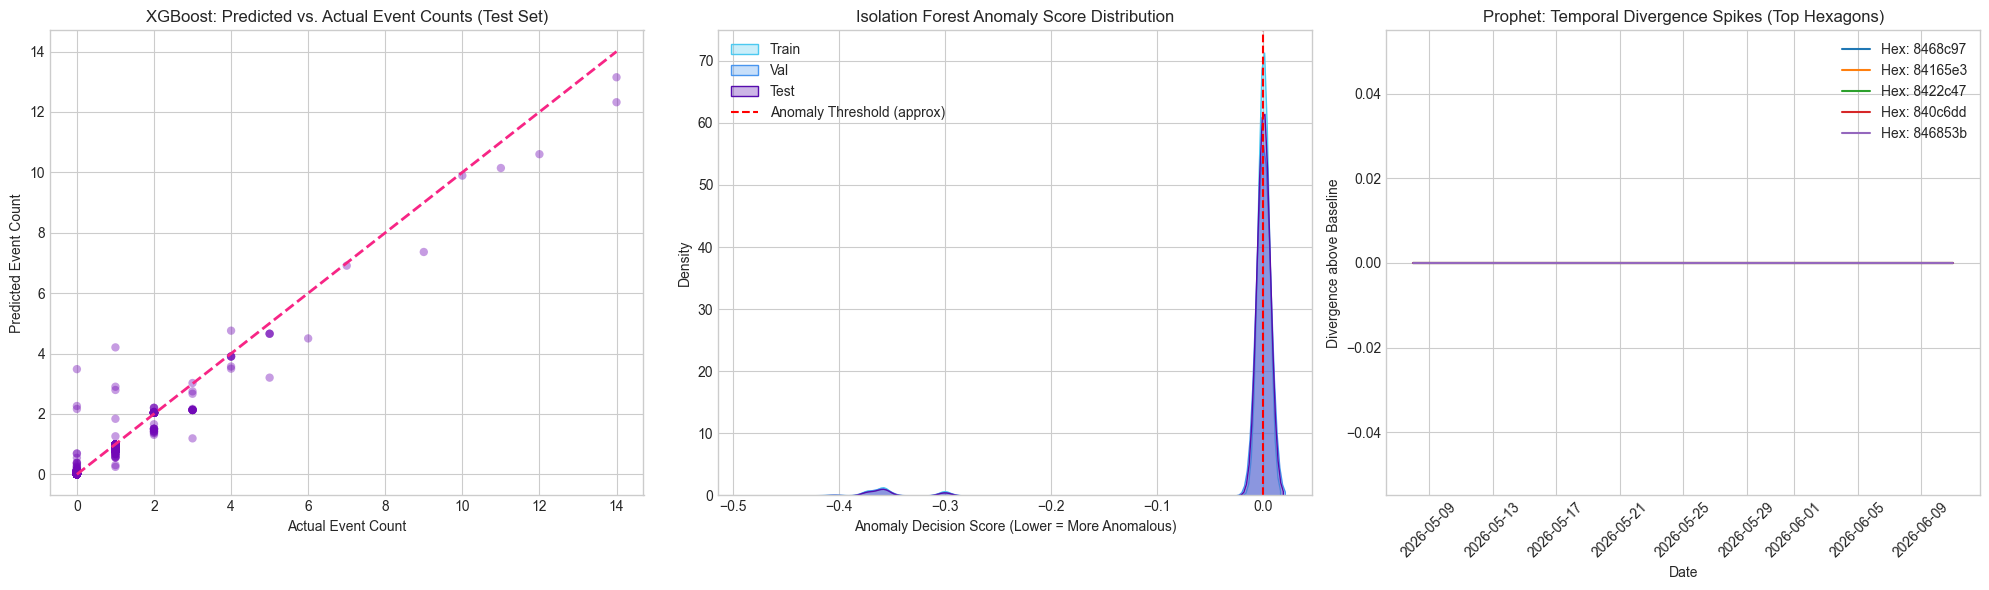

Evaluations plot saved and logged as MLflow artifact: model_evaluation_comparisons.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: XGBoost Predictions vs. Actual (Test Set)
axes[0].scatter(y_test, xgb_pred_test, alpha=0.4, color='#7209b7', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='#f72585', linewidth=2)
axes[0].set_title('XGBoost: Predicted vs. Actual Event Counts (Test Set)')
axes[0].set_xlabel('Actual Event Count')
axes[0].set_ylabel('Predicted Event Count')

# Plot 2: Isolation Forest Anomaly Score Distributions
sns.kdeplot(train_anomaly_scores, label='Train', fill=True, ax=axes[1], color='#4cc9f0', alpha=0.3)
sns.kdeplot(val_anomaly_scores, label='Val', fill=True, ax=axes[1], color='#4895ef', alpha=0.3)
sns.kdeplot(test_anomaly_scores, label='Test', fill=True, ax=axes[1], color='#560bad', alpha=0.3)
axes[1].axvline(x=0.0, color='red', linestyle='--', label='Anomaly Threshold (approx)')
axes[1].set_title('Isolation Forest Anomaly Score Distribution')
axes[1].set_xlabel('Anomaly Decision Score (Lower = More Anomalous)')
axes[1].set_ylabel('Density')
axes[1].legend()

# Plot 3: Prophet Temporal Divergence Spikes (Top 5 Active Hexagons)
test_results_pd = test_results.to_pandas()
top_5_hexes = list(prophet_results.keys())[:5]
for hex_id in top_5_hexes:
    hex_data = test_results_pd[test_results_pd['h3_index'] == hex_id].sort_values('date_bucket')
    if not hex_data.empty:
        axes[2].plot(pd.to_datetime(hex_data['date_bucket']), hex_data['prophet_divergence'], label=f'Hex: {hex_id[:7]}')

axes[2].set_title('Prophet: Temporal Divergence Spikes (Top Hexagons)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Divergence above Baseline')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
# Save plots as artifact
plot_path = 'model_evaluation_comparisons.png'
plt.savefig(plot_path, dpi=300)
plt.show()

# Log plot to MLflow
with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(plot_path)
    print(f"Evaluations plot saved and logged as MLflow artifact: {plot_path}")